Dynamic Pricing Engine

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
import os

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

VIS_FOLDER = "Visualizations"
os.makedirs(VIS_FOLDER, exist_ok=True)

STREAMLIT_FOLDER = "streamlit_assets"
os.makedirs(STREAMLIT_FOLDER, exist_ok=True)

In [2]:
EVENTS_PATH = 'ModelData/events.csv'
PRODUCTS_PATH = 'ModelData/products.csv'
SESSIONS_PATH = 'ModelData/sessions.csv'
CUSTOMERS_PATH = 'ModelData/customers.csv'

df_events = pd.read_csv(EVENTS_PATH)
df_products = pd.read_csv(PRODUCTS_PATH)
df_sessions = pd.read_csv(SESSIONS_PATH)
df_customers = pd.read_csv(CUSTOMERS_PATH)

datasets = {
    "Events": df_events,
    "Products": df_products,
    "Sessions": df_sessions,
    "Customers": df_customers
}

print("**Details of DataFrame Content**")
for name, df in datasets.items():
    print(f"Name: {name}, Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    print(f"Identity Fields in {name}:")
    for i in df.columns:
        if '_id' in i:
            print(i)

**Details of DataFrame Content**
Name: Events, Rows: 760958, Columns: 10
Identity Fields in Events:
event_id
session_id
product_id
Name: Products, Rows: 1197, Columns: 6
Identity Fields in Products:
product_id
Name: Sessions, Rows: 120000, Columns: 6
Identity Fields in Sessions:
session_id
customer_id
Name: Customers, Rows: 20000, Columns: 7
Identity Fields in Customers:
customer_id


In [3]:
#creating the master dataframe

df_merged = pd.merge(df_events, df_products, on='product_id', how='left')
df_merged = pd.merge(df_merged, df_sessions, on='session_id', how='left')
masterdf = pd.merge(df_merged, df_customers, on='customer_id', how='left')

print("**Structural Overview* of Master DataFrame*")
print(masterdf.info())

**Structural Overview* of Master DataFrame*
<class 'pandas.DataFrame'>
RangeIndex: 760958 entries, 0 to 760957
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   event_id          760958 non-null  int64  
 1   session_id        760958 non-null  int64  
 2   timestamp         760958 non-null  str    
 3   event_type        760958 non-null  str    
 4   product_id        682469 non-null  float64
 5   qty               143126 non-null  float64
 6   cart_size         44909 non-null   float64
 7   payment           33580 non-null   str    
 8   discount_pct      33580 non-null   float64
 9   amount_usd        33580 non-null   float64
 10  category          682469 non-null  str    
 11  name_x            682469 non-null  str    
 12  price_usd         682469 non-null  float64
 13  cost_usd          682469 non-null  float64
 14  margin_usd        682469 non-null  float64
 15  customer_id       760958 non-null  

**Total successful purchase orders captured: 33,580**


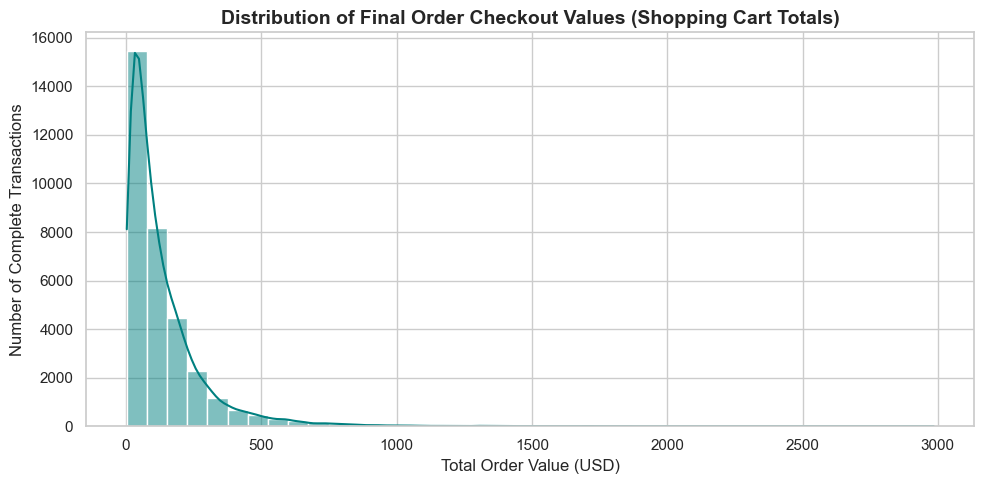

<Figure size 640x480 with 0 Axes>

In [4]:
#extracting data from completed purchases
purchase_events = masterdf[masterdf['event_type'] == 'purchase']

print(f"**Total successful purchase orders captured: {len(purchase_events):,}**")

plt.figure(figsize=(10, 5))
sns.histplot(data=purchase_events, x='amount_usd', bins=40, color='teal', kde=True)

plt.title("Distribution of Final Order Checkout Values (Shopping Cart Totals)", fontsize=14, fontweight='bold')
plt.xlabel("Total Order Value (USD)", fontsize=12)
plt.ylabel("Number of Complete Transactions", fontsize=12)
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(VIS_FOLDER, 'price_distribution_chart.png'), dpi=300, bbox_inches='tight')

In [5]:
# grouping purchases with session_ids
purchased_sessions = set(masterdf[masterdf['event_type'] == 'purchase']['session_id'])

# getting total sum of add_to_carts and page_views for each product_id
page_views = masterdf[masterdf['event_type'] == 'page_view'].groupby('product_id').size().rename('page_view')
add_to_carts = masterdf[masterdf['event_type'] == 'add_to_cart'].groupby('product_id').size().rename('add_to_cart')

cart_events = masterdf[masterdf['event_type'] == 'add_to_cart'].copy()
# adding all the add_to_cart event types where it leads to a puchase by giving it a binary value
# only add_to_cart event types have product_ids
cart_events['is_purchased'] = cart_events['session_id'].isin(purchased_sessions).astype(int)
# product_id and their number of purchases
product_purchases = cart_events.groupby('product_id')['is_purchased'].sum().rename('purchase_count')

# all metics are joined using this line of cmd
product_base = df_products.set_index('product_id')[['price_usd', 'cost_usd', 'category']]

# joining financial data with features
features_df = product_base.join(page_views,how='left').fillna(0)
features_df = features_df.join(add_to_carts, how='left').fillna(0)
features_df = features_df.join(product_purchases, how='left').fillna(0)

# creating advanced features to train the model
features_df['click_velocity'] = features_df['page_view']
features_df['cart_to_view_ratio'] = features_df['add_to_cart'] / features_df['page_view'].fillna(0)
features_df['conversion_rate'] = features_df['purchase_count'] / features_df['page_view'].fillna(0)
features_df['gross_margin_pct'] = ((features_df['price_usd'] - features_df['cost_usd']) / features_df['price_usd']).fillna(0)

# turns the product_id index used in formation of product_base back into a column label
features_df = features_df.reset_index()

print(f"**Shape of the Feature Matrix**: {features_df.shape[0]}")
features_df[['product_id', 'category', 'click_velocity', 'cart_to_view_ratio', 'conversion_rate', 'gross_margin_pct']].head()

**Shape of the Feature Matrix**: 1197


,product_id,category,click_velocity,cart_to_view_ratio,conversion_rate,gross_margin_pct
0,1.0,Electronics,187,0.026738,0.010695,0.381549
1,2.0,Electronics,200,0.025000,0.010000,0.471764
2,3.0,Electronics,214,0.051402,0.018692,0.435582
3,4.0,Electronics,357,0.089636,0.039216,0.427784
4,5.0,Electronics,566,0.234982,0.077739,0.330350


In [6]:
# defining the feature and target columns
feature_cols = ['price_usd', 'cost_usd', 'click_velocity', 'cart_to_view_ratio', 'gross_margin_pct']
target_col = 'conversion_rate' 

# setting the training metrics
X = features_df[feature_cols]
y = features_df[target_col]

# splitting on a 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("**Model Data Divisions**")
print(f"X_train: {X_train.shape[0]} rows, {X_train.shape[1]} columns")
print(f"X_test: {X_test.shape[0]} rows, {X_test.shape[1]} columns")

**Model Data Divisions**
X_train: 957 rows, 5 columns
X_test: 240 rows, 5 columns


In [7]:
print("**Training the Demand Forecasting Model**")

# initialize the Random Forest model with 100 decision trees
pricing_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# training the model on the training data split
pricing_model.fit(X_train, y_train)

# predict the conversion rates for the test set
y_pred = pricing_model.predict(X_test)

# metrics to evaluate the model's performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("**Model Performance Evaluation**")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared: {r2:.4f}")

**Training the Demand Forecasting Model**
**Model Performance Evaluation**
Mean Absolute Error: 0.0102
R-squared: 0.9046


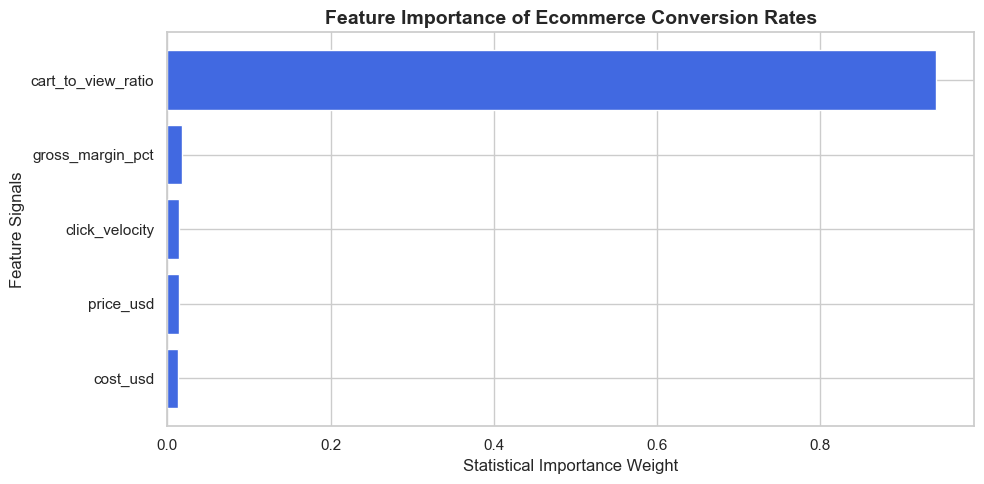

<Figure size 640x480 with 0 Axes>

In [8]:
# extracting importance weights calculated by the forest trees
importances = pricing_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    "Importance": importances
}).sort_values(by='Importance', ascending=True)

# plotting the weights
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.title("Feature Importance of Ecommerce Conversion Rates", fontsize=14, fontweight='bold')
plt.xlabel("Statistical Importance Weight", fontsize=12)
plt.ylabel("Feature Signals", fontsize=12)
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(VIS_FOLDER, 'feature_importance_of_conversion_rates.png'), dpi=300, bbox_inches='tight')

In [9]:
# dynamic pricing engine
def dynamic_pricing_engine(product_id, test_features_df, trained_model):
    # series from the dataframe
    prod_data = test_features_df[test_features_df['product_id'] == product_id].iloc[0]

    wholesale_cost = prod_data['cost_usd']
    original_price = prod_data['price_usd']
    click_velocity = prod_data['click_velocity']
    cart_ratio = prod_data['cart_to_view_ratio']

    # simulating a range of 100 possible prices from cost to 2.5x the original price
    simulated_prices = np.linspace(wholesale_cost + 1.0, original_price * 2.5, 100)

    best_price = original_price
    # to start the comparisons
    max_expected_profit = -float('inf')
    optimization_records = []
    
    for sim_price in simulated_prices:
        sim_margin = (sim_price - wholesale_cost) / sim_price

        input_payload = pd.DataFrame([{
            'price_usd': sim_price,
            'cost_usd': wholesale_cost,
            'click_velocity': click_velocity,
            'cart_to_view_ratio': cart_ratio,
            'gross_margin_pct': sim_margin
        }])

        predicted_conversion = trained_model.predict(input_payload)[0]
        expected_profit = (sim_price - wholesale_cost) * (predicted_conversion * click_velocity)
        optimization_records.append((sim_price, expected_profit))

        if expected_profit > max_expected_profit:
            max_expected_profit = expected_profit
            best_price = sim_price
    
    return original_price, round(best_price, 2), round(max_expected_profit, 2), optimization_records

# calling the function
orig, optimized, profit, details = dynamic_pricing_engine(product_id=4.0, test_features_df=features_df, trained_model=pricing_model)

print(f"**Live Engine Optimization Room Run for Product #4**")
print(f"Original Store Catalog Retail Price: ${orig:.2f}")
print(f"Engine Recommended Optimized Price: ${optimized:.2f}")
print(f"Maximum Projected Expected Profit: ${profit:.2f}")    

**Live Engine Optimization Room Run for Product #4**
Original Store Catalog Retail Price: $268.36
Engine Recommended Optimized Price: $670.90
Maximum Projected Expected Profit: $6718.44


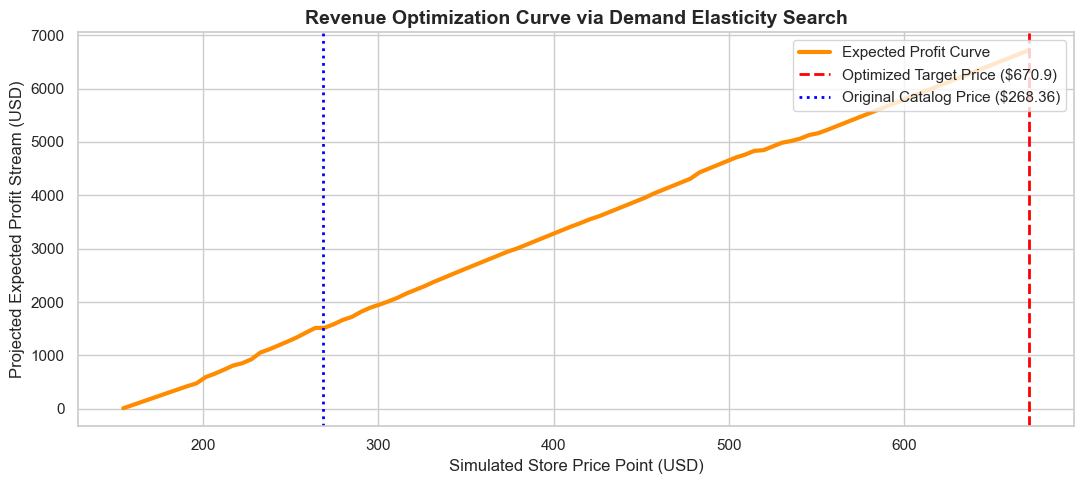

<Figure size 640x480 with 0 Axes>

In [10]:
# Convert optimization loop history matrix into a plot-friendly layout
plot_df = pd.DataFrame(details, columns=['Simulated_Price', 'Expected_Profit'])

plt.figure(figsize=(11, 5))
plt.plot(plot_df['Simulated_Price'], plot_df['Expected_Profit'], color='darkorange', linewidth=3, label='Expected Profit Curve')

# Add explicit line pointers for business visualization
plt.axvline(x=optimized, color='red', linestyle='--', linewidth=2, label=f'Optimized Target Price (${optimized})')
plt.axvline(x=orig, color='blue', linestyle=':', linewidth=2, label=f'Original Catalog Price (${orig:.2f})')

plt.title("Revenue Optimization Curve via Demand Elasticity Search", fontsize=14, fontweight='bold')
plt.xlabel("Simulated Store Price Point (USD)", fontsize=12)
plt.ylabel("Projected Expected Profit Stream (USD)", fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(VIS_FOLDER, 'revenue_optimization_curve.png'), dpi=300, bbox_inches='tight')

for Streamlit

In [11]:
print("**Packaging and Organizing Production Streamlit Assets**")

# 1. Serialize and export your trained Random Forest model object
model_dest = os.path.join(STREAMLIT_FOLDER, 'dynamic_pricing_rf_model.pkl')
joblib.dump(pricing_model, model_dest)
print(f"Trained machine learning model exported to: {model_dest}")

# 2. Export the structural column metadata schema alignment rules
schema_dest = os.path.join(STREAMLIT_FOLDER, 'model_feature_schema.pkl')
joblib.dump(feature_cols, schema_dest)
print(f"Model layout schema structural list exported to: {schema_dest}")

# 3. Save your engineered features dataset to a standalone CSV for Streamlit loading
csv_dest = os.path.join(STREAMLIT_FOLDER, 'features_df.csv')
features_df.to_csv(csv_dest, index=False)
print(f"Standalone analytical features data matrix exported to: {csv_dest}")

**Packaging and Organizing Production Streamlit Assets**
Trained machine learning model exported to: streamlit_assets\dynamic_pricing_rf_model.pkl
Model layout schema structural list exported to: streamlit_assets\model_feature_schema.pkl
Standalone analytical features data matrix exported to: streamlit_assets\features_df.csv


In [12]:
total_products = len(features_df)
avg_velocity = features_df['click_velocity'].mean()
avg_conversion = features_df['conversion_rate'].mean()

print(f"**Stats**")
print(f"Products Monitored     : {total_products:,} distinct catalog items")
print(f"Average Click Velocity : {avg_velocity:.1f} page views per item")
print(f"Baseline Conversion    : {avg_conversion*100:.2f}% checkout success rate")

**Stats**
Products Monitored     : 1,197 distinct catalog items
Average Click Velocity : 450.6 page views per item
Baseline Conversion    : 9.98% checkout success rate
